In [1]:
import os
import rippl_AI
import importlib
importlib.reload(rippl_AI)
import load_fcn

import matplotlib.pyplot as plt
import numpy as np
%matplotlib qt

In [2]:
from figshare.figshare import Figshare
fshare = Figshare()

article_ids = [14959449] 
sess=['Dlx1']                                  
for id,s in zip(article_ids,sess):
    datapath = os.path.join('Downloaded_data', f'{s}')
    if os.path.isdir(datapath):
        print("Data already exists. Moving on.")
    else:
        print("Downloading data... Please wait, this might take up some time")        # Can take up to 10 minutes
        fshare.retrieve_files_from_article(id,directory=datapath)
        print("Data downloaded!")

Data already exists. Moving on.


# Use Parida lab data

In [2]:
import load_fcn
import os

path=os.path.join('Downloaded_data','Dlx1','figshare_14959449')

sf, expName, ref_channels, dead_channels = load_fcn.load_info(path)
channels_map = load_fcn.load_channels_map(path)

# Reformat channels into correct values
channels, shanks, ref_channels = load_fcn.reformat_channels(channels_map, ref_channels)
# Read .dat
print('Channel map value: ',channels)
LFP = load_fcn.load_raw_data(path, expName, channels, verbose=True)
print('Sampling frequency: ', sf)
print('Shape of the original data',LFP.shape)
print(channels_map)

Channel map value:  [0, 1, 2, 3, 4, 5, 6, 7]
Downloaded_data\Dlx1\figshare_14959449/lfp_Dlx1-2021-02-12_12-46-54.dat
fileStart  0
fileStop  490242048
nSamples  245121024
nSamplesPerChannel  30640128
nSamplesPerChunk  10000
size data  30640128
Sampling frequency:  30000
Shape of the original data (30640128, 8)
[[1 1 2]
 [2 1 2]
 [3 1 2]
 [4 1 2]
 [5 1 2]
 [6 1 2]
 [7 1 2]
 [8 1 2]]


Downsampling data from 30000 to 1250 Hz...
Shape of downsampled data: (1276672, 8)
Normalizing data...
LSTM_1_Ch8_W60_Ts32_Bi0_L4_U11_E10_TB256
1247/1247 [==============================] - 4s 3ms/step


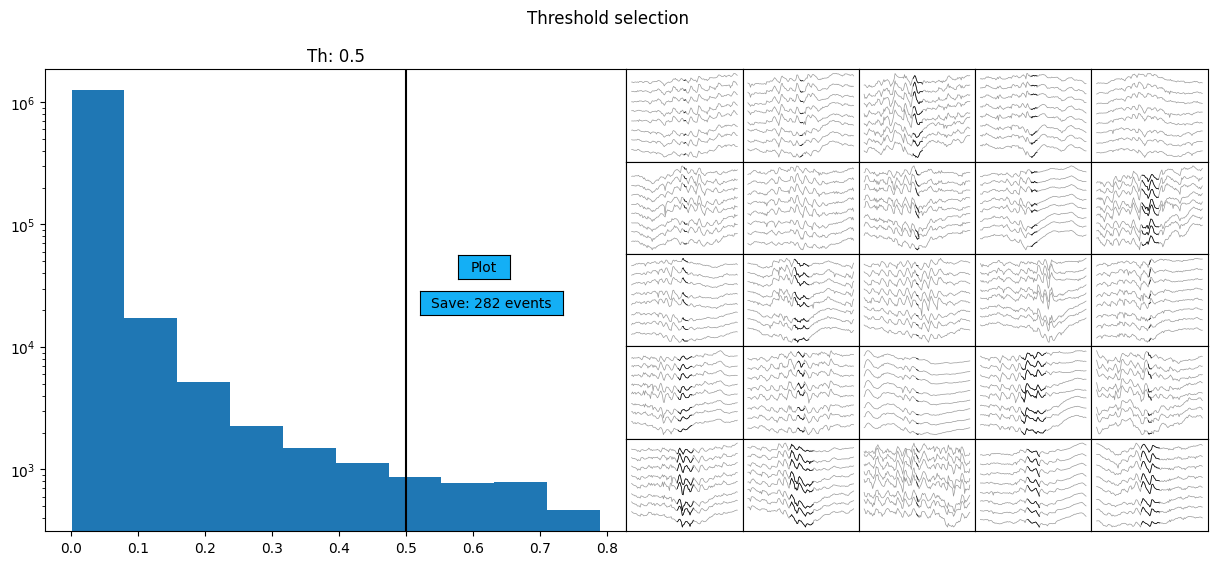

282 events where detected
precision = 0.8475177304964538
recall = 0.6540284360189573
F1 = 0.7383065644412111


In [ ]:
# run ripple AI
import rippl_AI
# comment out this line if don't want interactive GUI:
# %matplotlib qt 


# Run prediction
dsf = 1250  # Define the downsampled frequency
prob, LFP_norm = rippl_AI.predict(LFP, sf, d_sf=dsf, arch="LSTM")  # run prediction on the data
# An interactive GUI will be displayed, choose your deired threshold
predicted=rippl_AI.get_intervals(prob,LFP_norm=LFP_norm) 
print(f"{predicted.shape[0]} events where detected")

# Evaluate performance
from aux_fcn import get_performance
true = load_fcn.load_ripples(path)/sf


precision = 0.8475177304964538
recall = 0.6540284360189573
F1 = 0.7383065644412111
Number of true positives: 239
Number of false positives: 43
Number of false negatives: 73


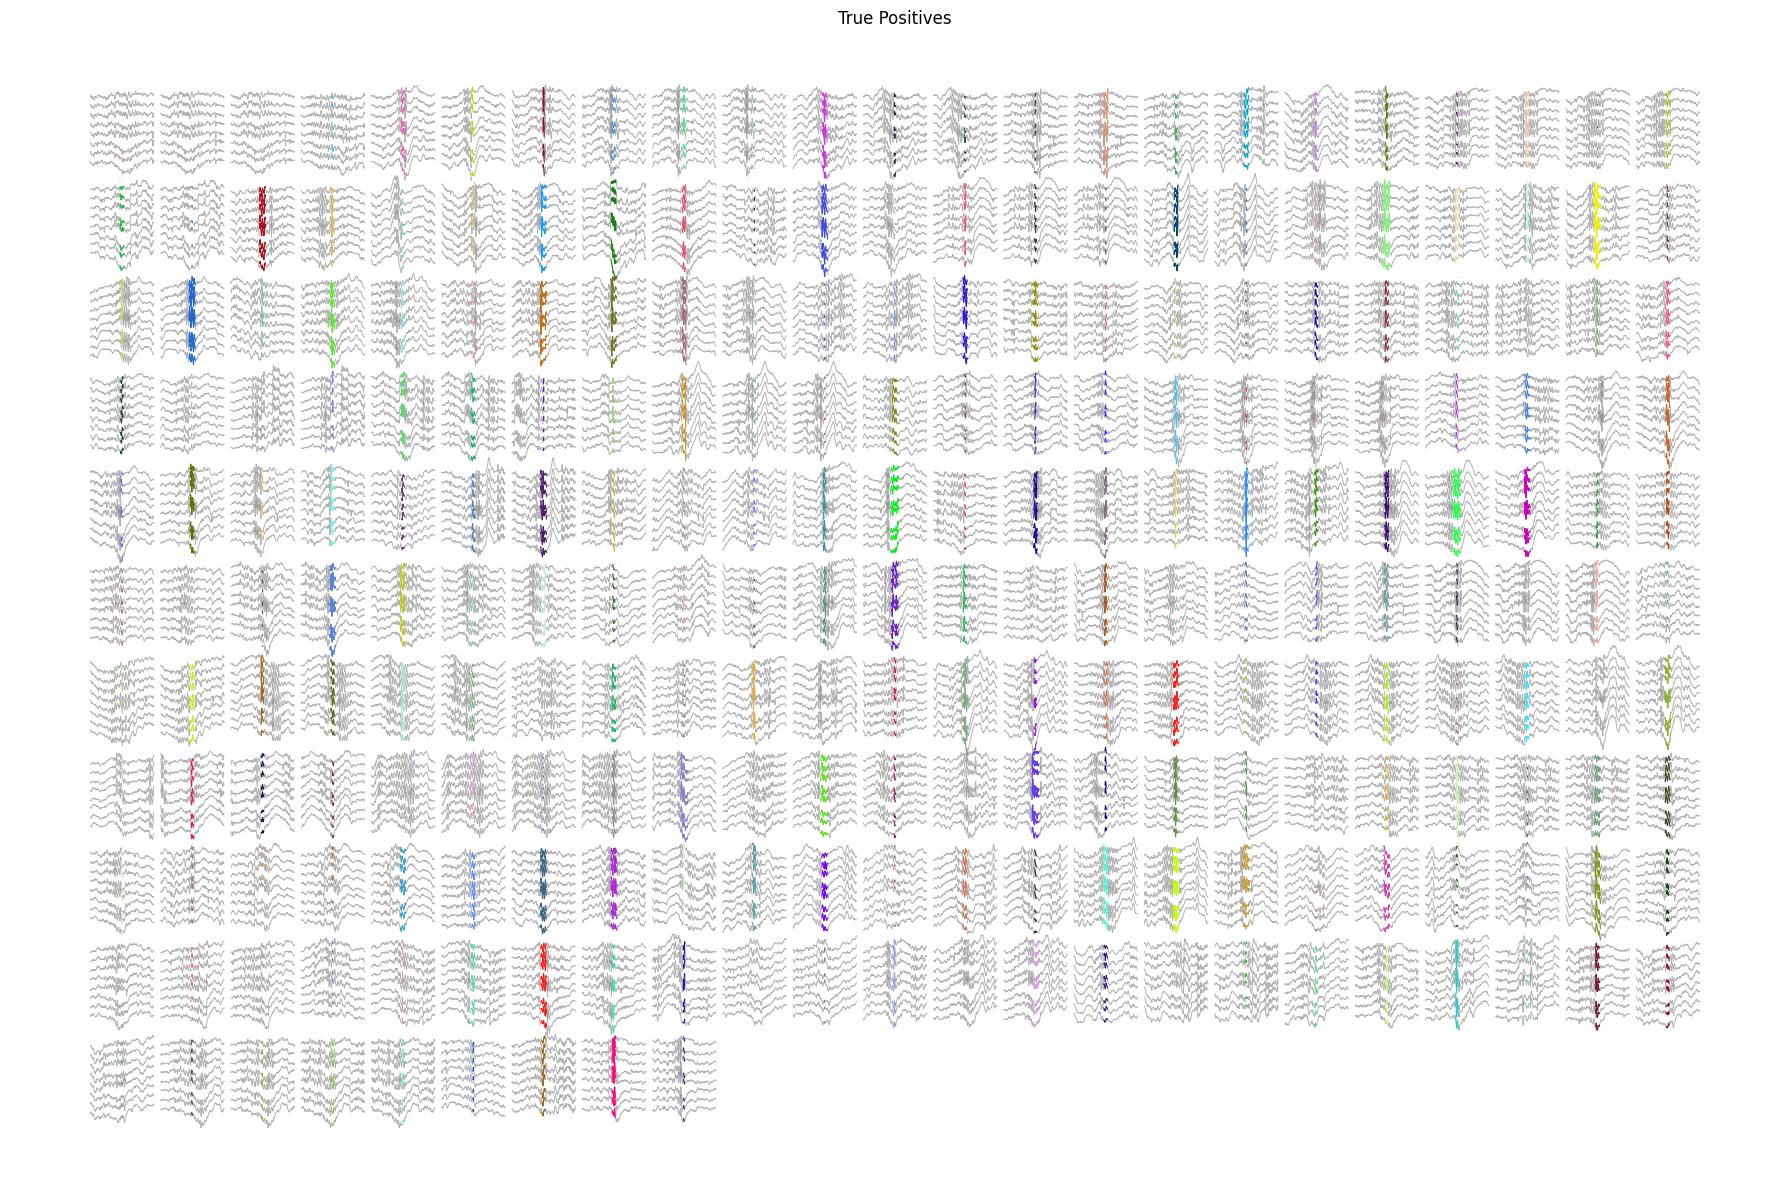

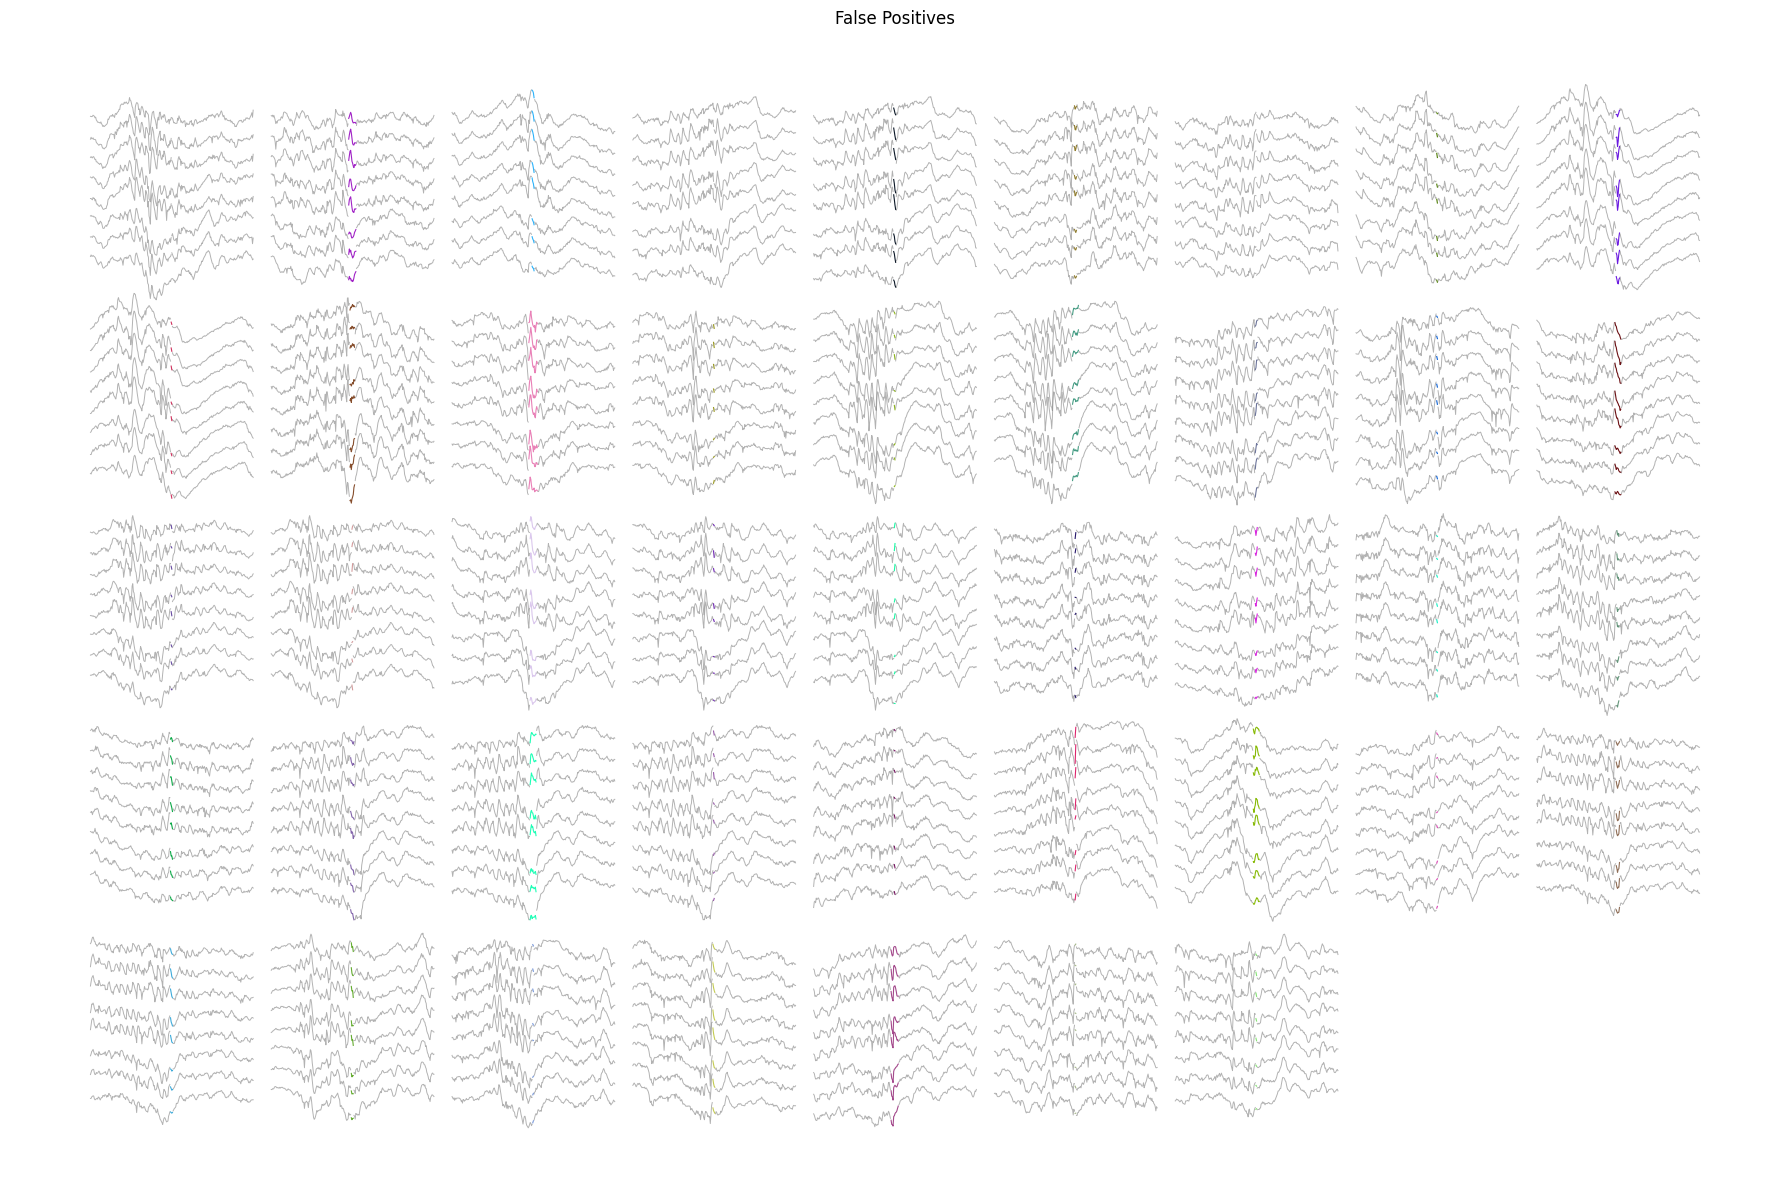

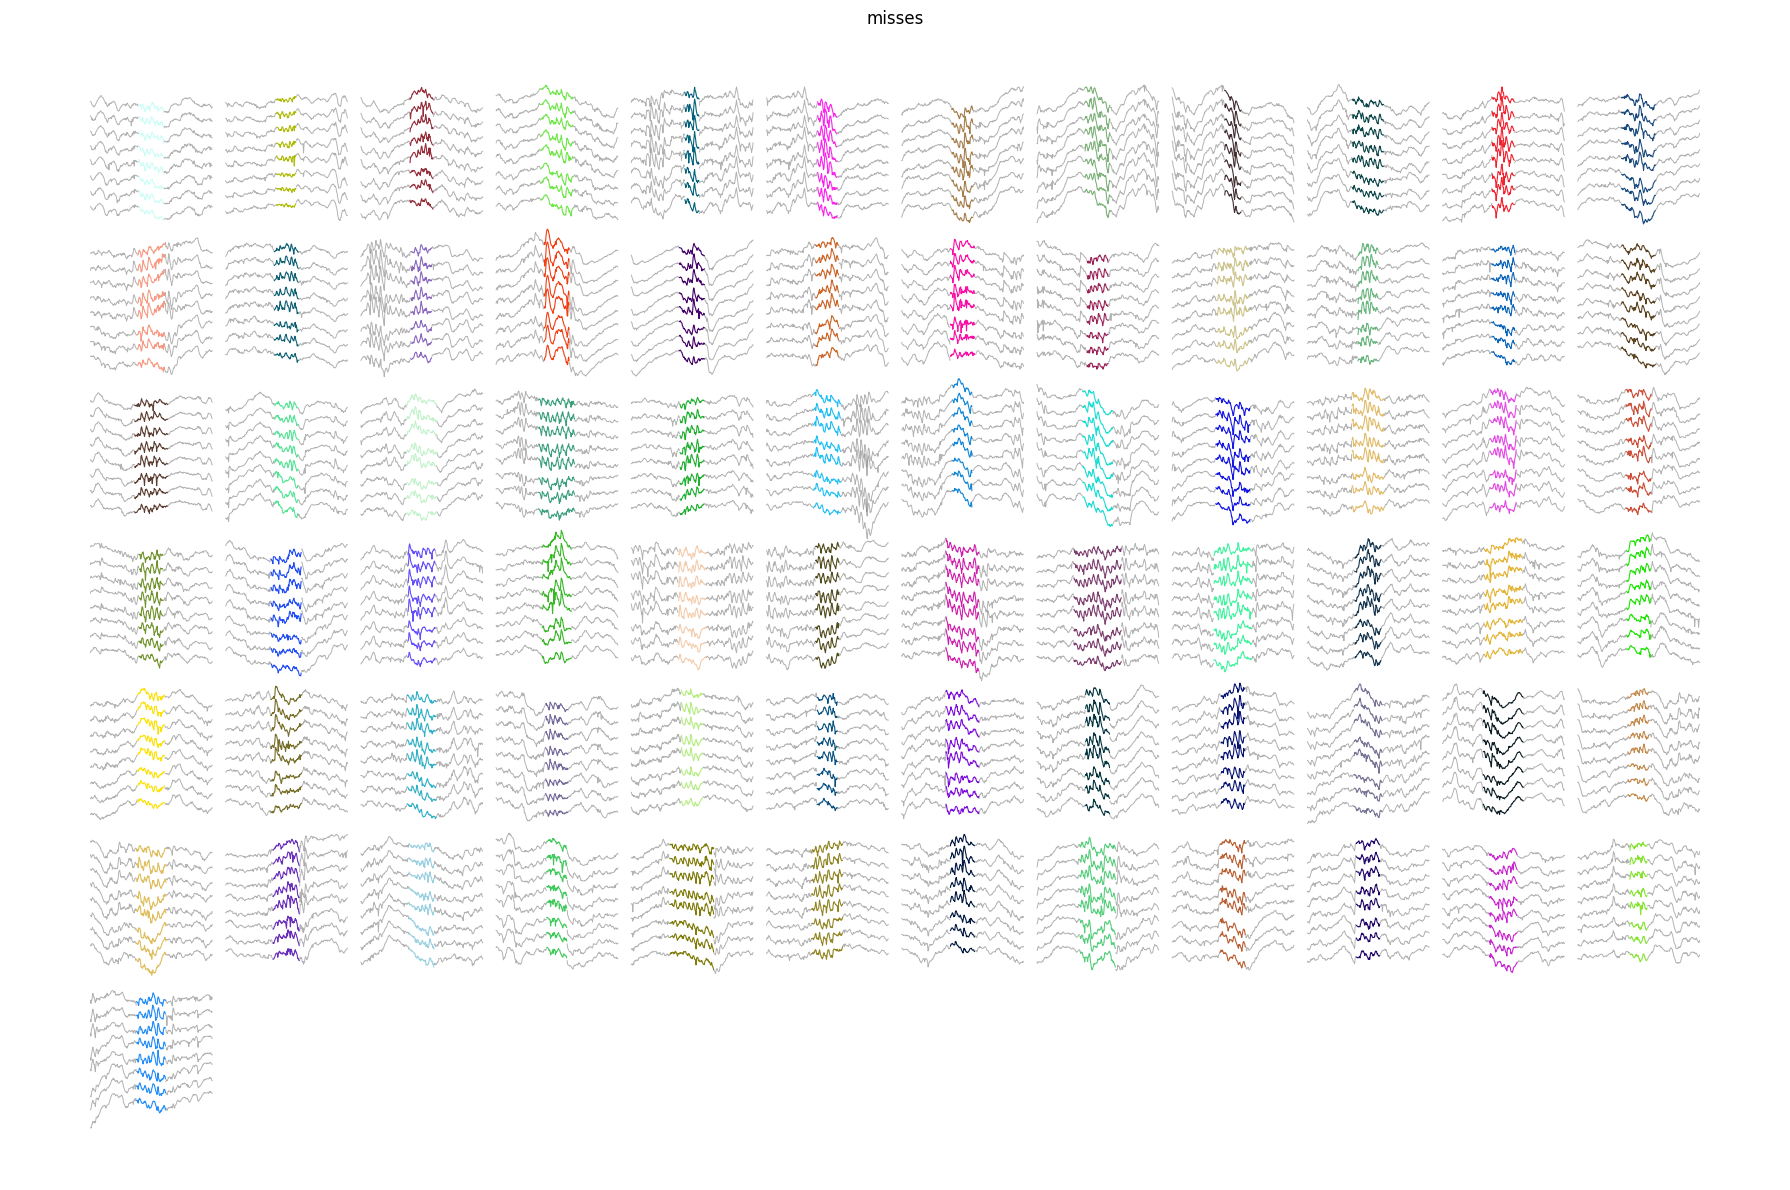

In [50]:
# visualize examples of True positives and false positives
from eval_fcn import get_performance, plot_all_events
import numpy as np
%matplotlib inline

precision, recall, F1, TP, FN, IOU  = get_performance(predicted, true, threshold=0, exclude_matched_trues=False, verbose=True)

mid = (predicted[:,1] - predicted[:,0])/2 + predicted[:,0]
id_tp = np.where(TP)[0]
id_fp = np.where(~TP)[0]
id_fn = np.where(FN)[1]


print(f"Number of true positives: {len(id_tp)}")
print(f"Number of false positives: {len(id_fp)}")
print(f"Number of false negatives: {len(id_fn)}")

# Plot true positives
plot_all_events(predicted[id_tp, :], LFP_norm, dsf, title='True Positives')
    
# Plot false positives
plot_all_events(predicted[id_fp, :], LFP_norm, dsf, title='False Positives')

# maybe plot misses too, this index should be for the true sets
plot_all_events(true[id_fn, :], LFP_norm, dsf, title='misses')

# Try on Allen data

In [ ]:
allen_dat_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_719161530_729445648.npy"
sr = 1250
import numpy as np

allen_LFP = np.load(allen_dat_path)
print(allen_LFP.shape)
# run prediction on the Allen data
prob,LFP_norm=rippl_AI.predict(allen_LFP,sr) 

(12081228, 8)


In [10]:
# An interactive GUI will be displayed, choose your deired threshold
det_ind=rippl_AI.get_intervals(prob,LFP_norm=LFP_norm) 
print(f"{det_ind.shape[0]} events where detected")

3629 events where detected


# Allen data different session (better quality?)

In [13]:
allen_dat_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_754312389_756781561.npy"
sr = 1250
import numpy as np

allen_LFP = np.load(allen_dat_path)
print(allen_LFP.shape)
# run prediction on the Allen data
prob,LFP_norm=rippl_AI.predict(allen_LFP,sr,arch="XGBOOST") 

(12094351, 8)
Downsampling data from 1250 to 1250 Hz...
No downsaple is required
Shape of downsampled data: (12094351, 8)
Normalizing data...
XGBOOST_1_Ch8_W60_Ts016_D7_Lr0.10_G0.25_L10_SCALE1


In [14]:
LFP_norm.shape

(12094351, 8)

In [15]:
# An interactive GUI will be displayed, choose your deired threshold
det_ind=rippl_AI.get_intervals(prob,LFP_norm=allen_LFP) 
print(f"{det_ind.shape[0]} events where detected")

4750 events where detected
